## IMPORTING LIBRARIES

In [1]:
import pandas as pd;
import numpy as np;
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pickle

In [2]:
df=pd.read_csv('/content/train (1).csv')
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [3]:
df.shape

(800, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [5]:
print(df.isnull().sum())

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64


In [6]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [7]:
df['Class/ASD'].value_counts() ## imbalance data

,count
Class/ASD,
0,639
1,161


In [8]:
df['relation'].value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


In [9]:
df['used_app_before'].value_counts()

,count
used_app_before,
no,750
yes,50


In [10]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,257
?,203
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Others,29
Latino,17


In [11]:
df['age']=df['age'].astype(int)

In [12]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [13]:
for col in df.columns:
  num_features=['ID','age','result']
  if col not in num_features:
    print(col,df[col].unique())
    print('*'*100);

A1_Score [1 0]
****************************************************************************************************
A2_Score [0 1]
****************************************************************************************************
A3_Score [1 0]
****************************************************************************************************
A4_Score [0 1]
****************************************************************************************************
A5_Score [1 0]
****************************************************************************************************
A6_Score [0 1]
****************************************************************************************************
A7_Score [1 0]
****************************************************************************************************
A8_Score [0 1]
****************************************************************************************************
A9_Score [1 0]
*********************************************************

In [14]:
## drop id and age_Desc
df.drop(['ID','age_desc'],axis=1,inplace=True)
df.shape

(800, 20)

In [15]:
country_mapping={
    'United States': 'North America',
    'Brazil': 'South America',
    'Spain': 'Europe',
    'New Zealand': 'Oceania',
    'Bahamas': 'North America',
    'Viet Nam':'Vietnam',
    'Hong Kong':'China',
    'Austria':'Europe',
    'Argentina':'South America',
    'Jordan':'Asia',
    'Ireland':'Europe',
    'India':'Asia',
    'AmericanSamoa':'United States'
}

df['contry_of_res']=df['contry_of_res'].replace(country_mapping)
df['contry_of_res'].unique()

array(['Europe', 'Asia', 'North America', 'South Africa',
       'United Kingdom', 'South America', 'Oceania', 'Canada',
       'Kazakhstan', 'United Arab Emirates', 'Australia', 'Ukraine',
       'Iraq', 'France', 'Malaysia', 'Vietnam', 'Egypt', 'Netherlands',
       'Afghanistan', 'Oman', 'Italy', 'United States', 'Saudi Arabia',
       'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Tonga', 'Pakistan', 'Iran', 'Japan', 'Mexico',
       'Nicaragua', 'Sierra Leone', 'Czech Republic', 'Niger', 'Romania',
       'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'], dtype=object)

## Exploratory Data Analysis (EDA)

In [16]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [17]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


## Univariate Analysis

Text(0.5, 0, 'Class/ASD')

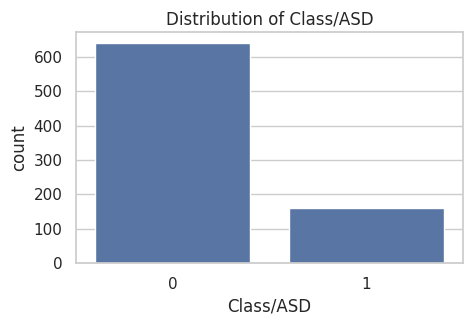

In [18]:
sns.set(style='whitegrid')
plt.figure(figsize=(5,3))
sns.countplot(x='Class/ASD',data=df)
plt.title('Distribution of Class/ASD')
plt.xlabel('Class/ASD')

Mean Age: 27.96375
Median Age: 24.0


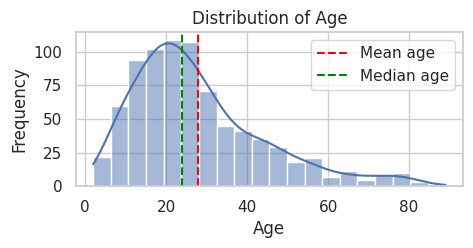

In [19]:
plt.figure(figsize=(5,2))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
age_mean=df['age'].mean()
age_median=df['age'].median()
print(f'Mean Age: {age_mean}')
print(f'Median Age: {age_median}')

plt.axvline(age_mean,color='red',linestyle='--',label='Mean age')
plt.axvline(age_median,color='green',linestyle='--',label='Median age')
plt.legend()
plt.grid(True)
plt.show()

Mean Result: 8.537303106501248
Median Result: 9.605299308


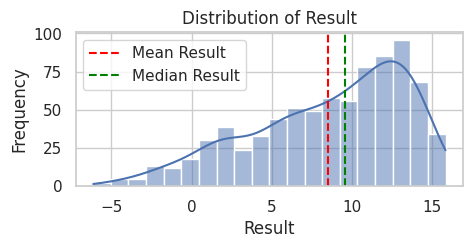

In [20]:
plt.figure(figsize=(5,2))
sns.histplot(df['result'],bins=20,kde=True)
plt.title('Distribution of Result')
plt.xlabel('Result')
plt.ylabel('Frequency')
result_mean=df['result'].mean()
result_median=df['result'].median()
print(f'Mean Result: {result_mean}')
print(f'Median Result: {result_median}')

plt.axvline(result_mean,color='red',linestyle='--',label='Mean Result')
plt.axvline(result_median,color='green',linestyle='--',label='Median Result')
plt.legend()
plt.grid(True)
plt.show()

## Boxplots

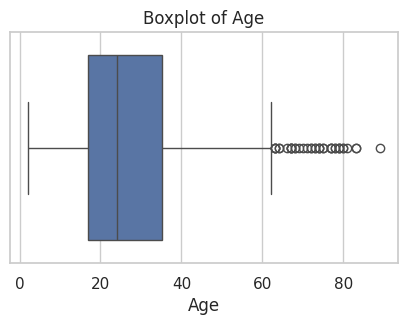

In [21]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

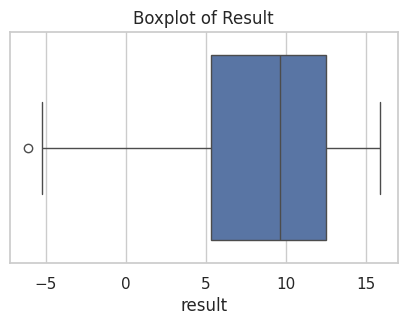

In [22]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['result'])
plt.title('Boxplot of Result')
plt.xlabel('result')
plt.show()

In [23]:
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
age_outliers=df[(df['age']<lower_bound)|(df['age']>upper_bound)]
print('Age outliers:')
print(len(age_outliers))

Age outliers:
39


In [24]:
Q1=df['result'].quantile(0.25)
Q3=df['result'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
result_outliers=df[(df['result']<lower_bound)|(df['result']>upper_bound)]
print('Result outliers:')
print(len(result_outliers))

Result outliers:
1


## Univariate analysis for categorical columns

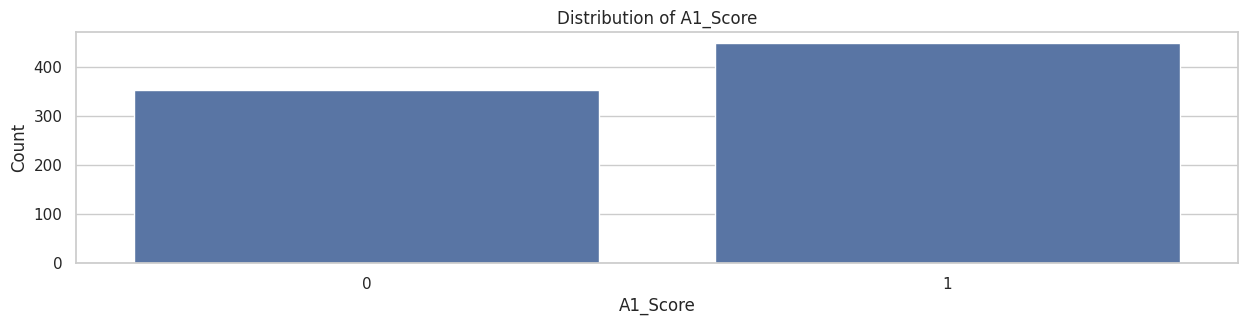

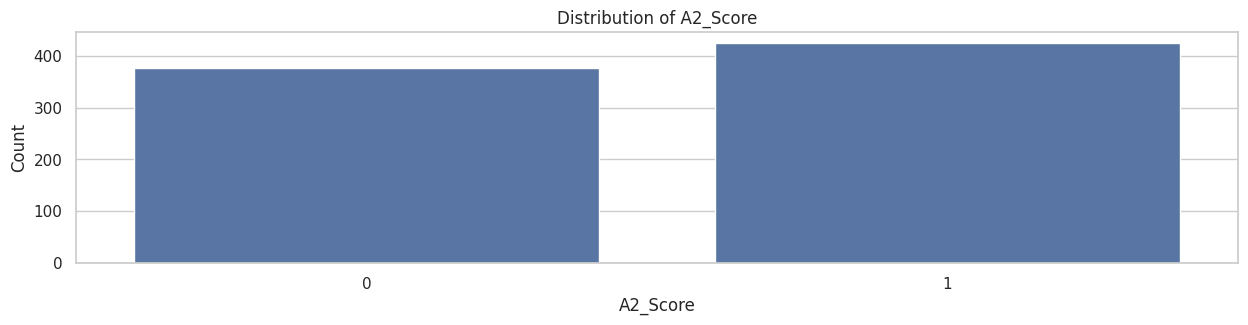

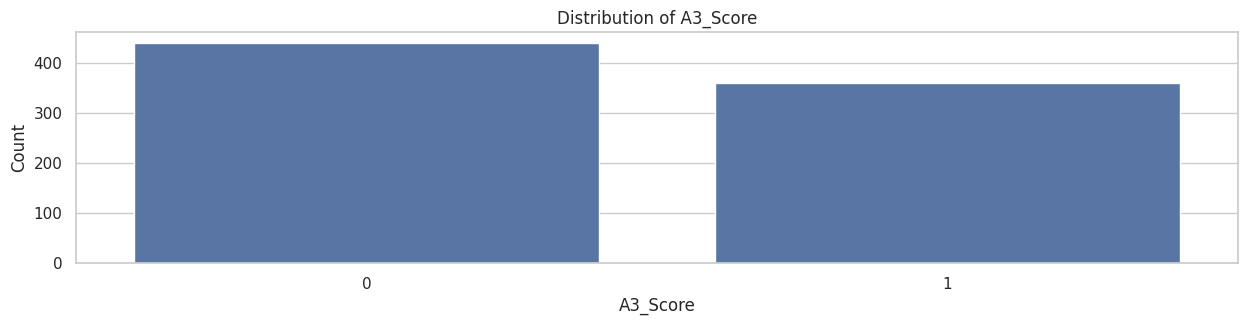

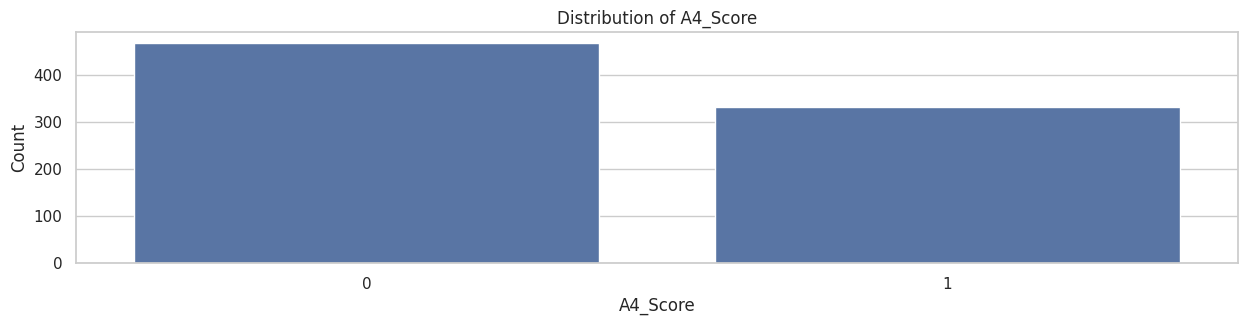

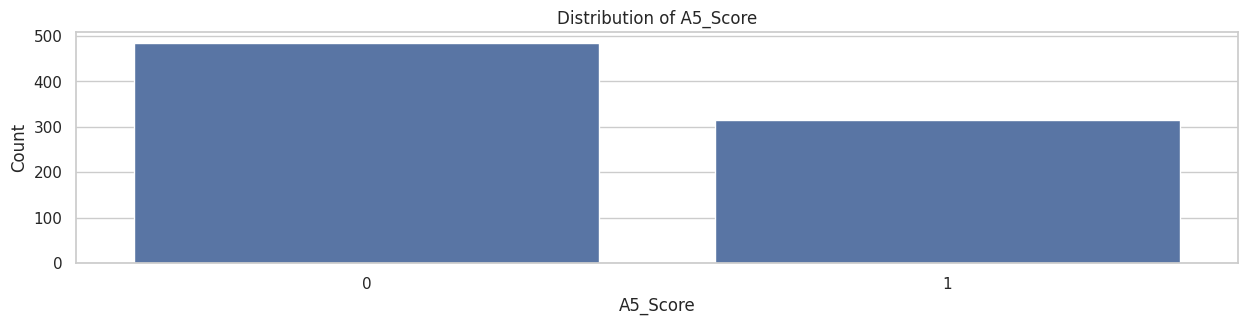

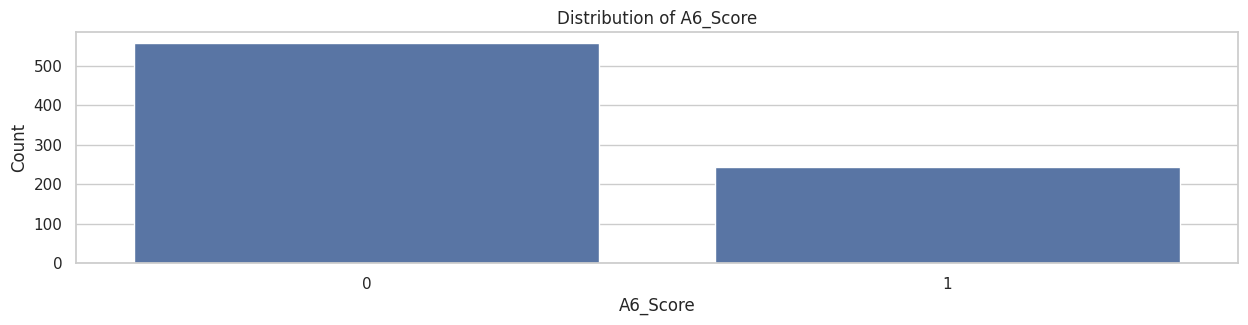

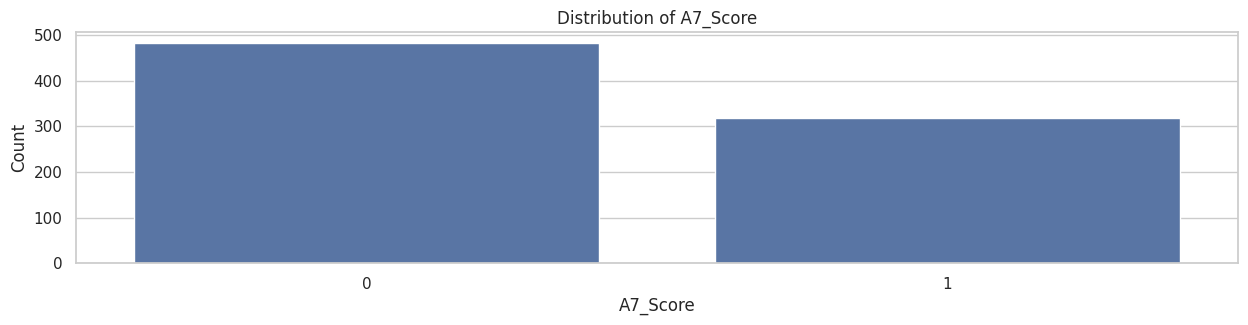

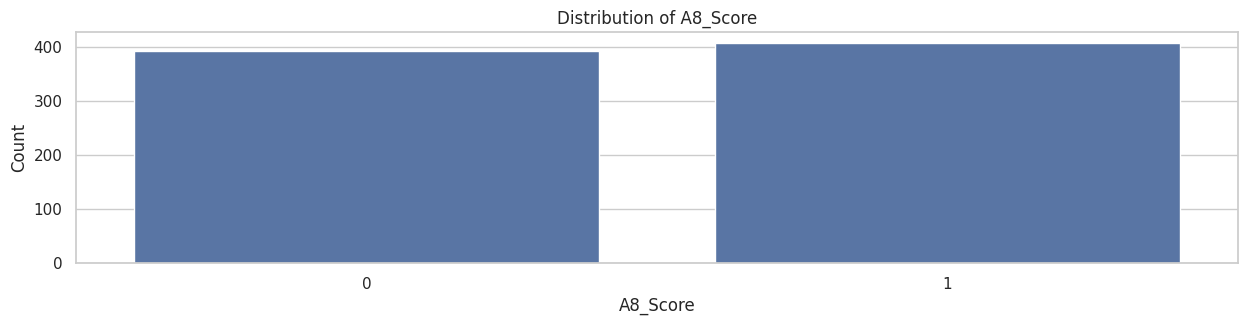

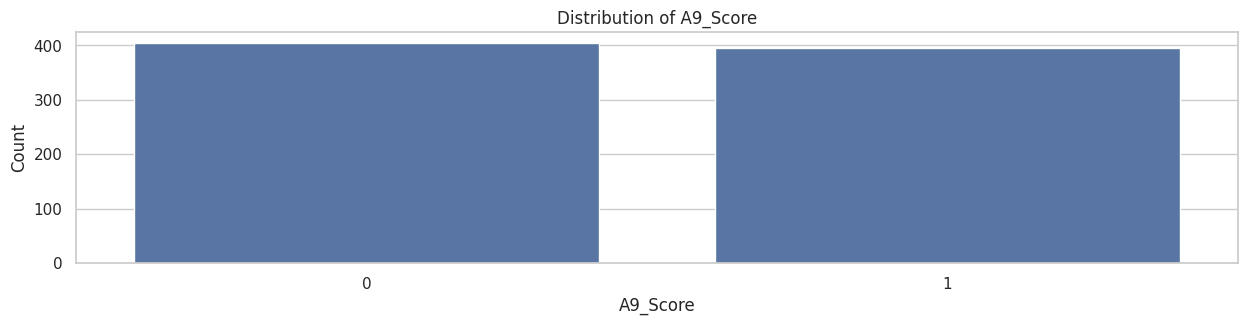

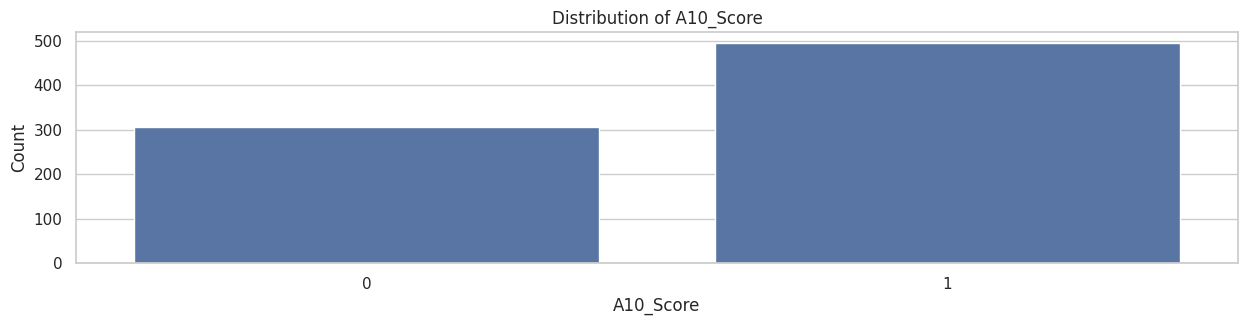

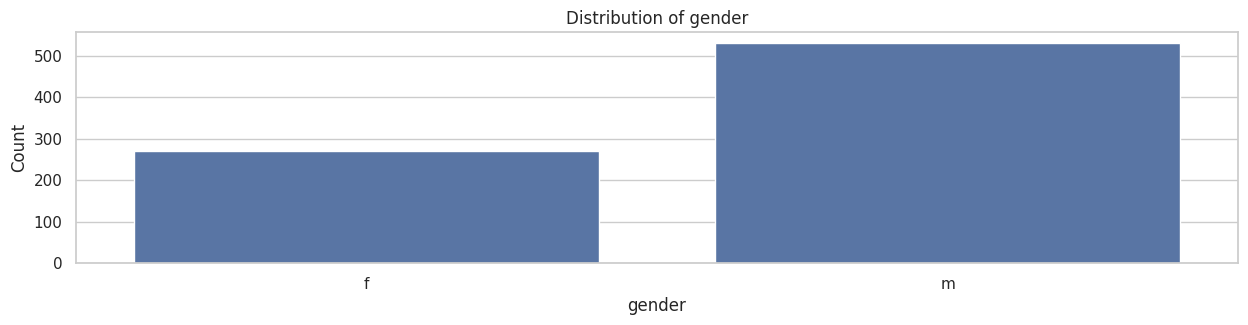

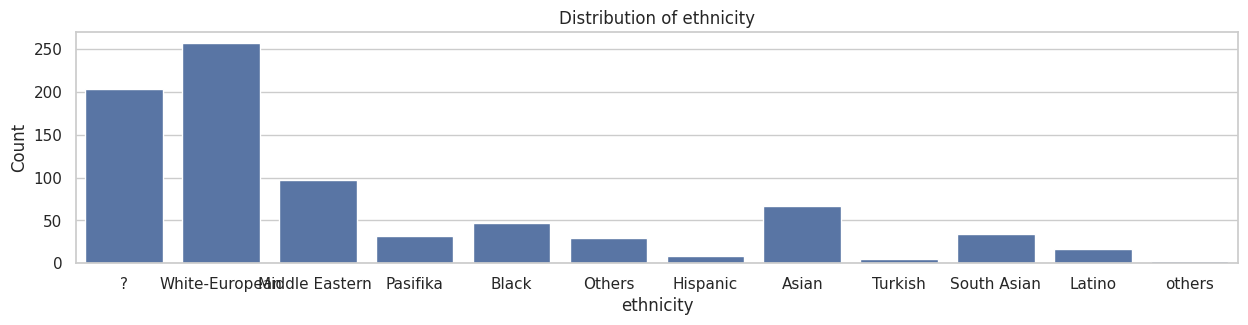

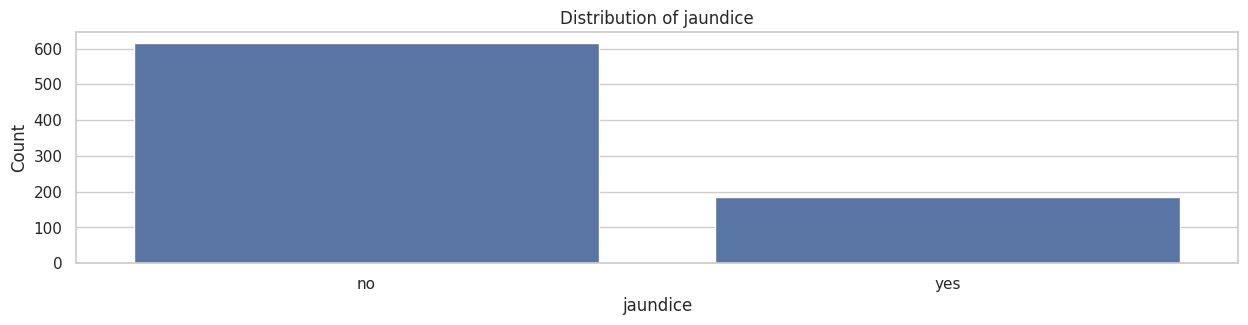

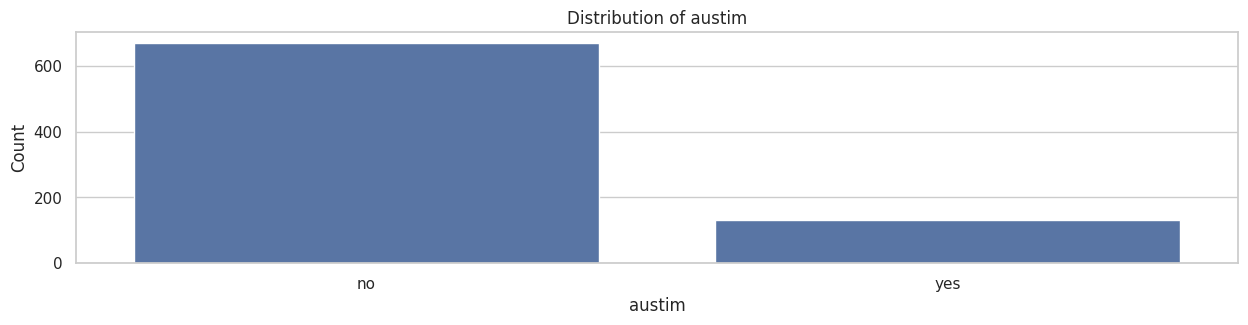

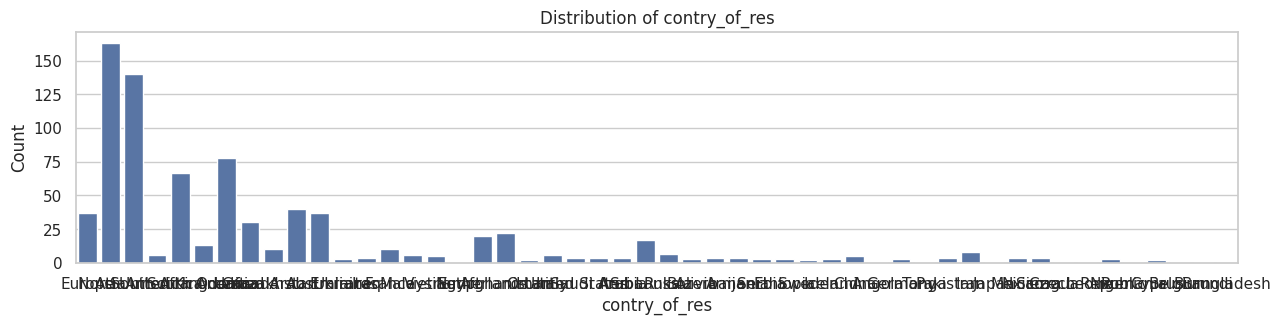

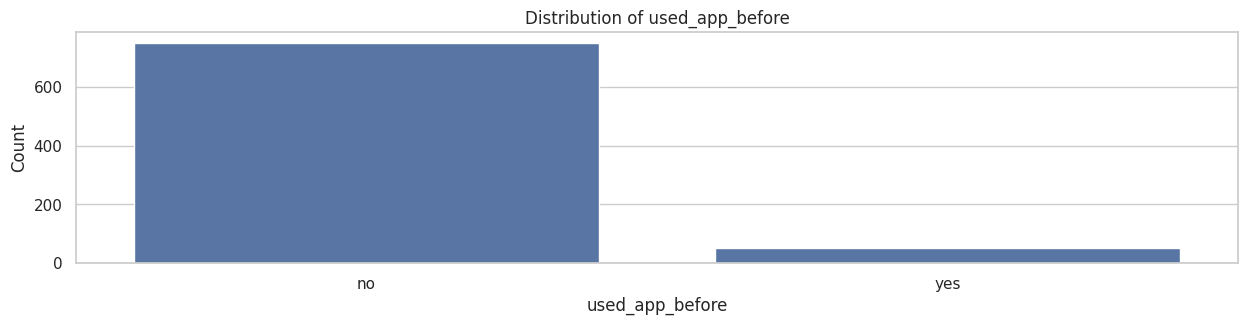

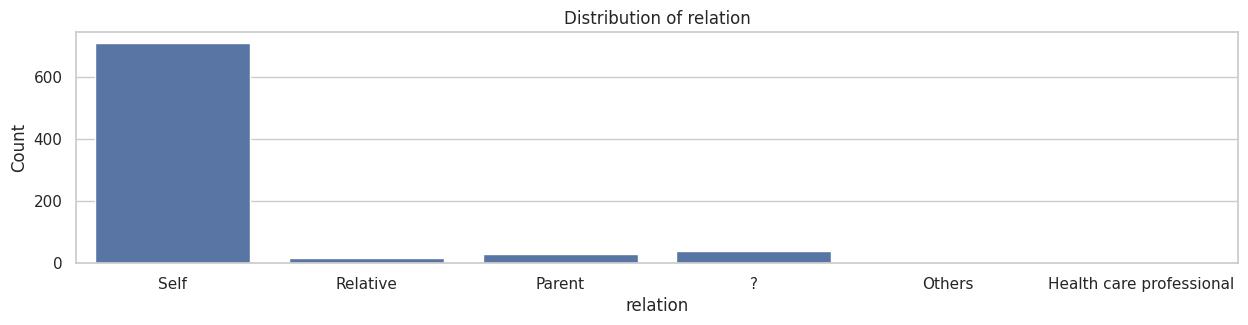

In [25]:
categorical_columns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']

for i in categorical_columns:
  plt.figure(figsize=(15,3))
  sns.countplot(x=i,data=df)
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Count')

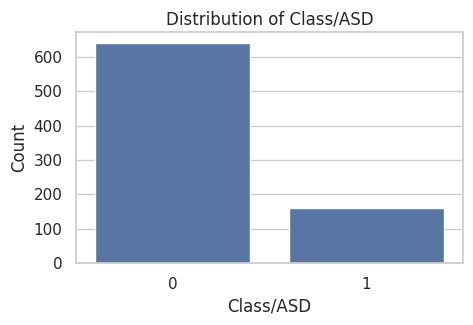

In [26]:
## for target column
plt.figure(figsize=(5,3))
sns.countplot(x='Class/ASD',data=df)
plt.title('Distribution of Class/ASD')
plt.xlabel('Class/ASD')
plt.ylabel('Count')
plt.show()

## Handle missing value or ?

In [27]:
df['ethnicity'].replace({'?':'Others','others':'Others'},inplace=True)
df['ethnicity'].unique()

<ipython-input-27-3f73fb88e59c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ethnicity'].replace({'?':'Others','others':'Others'},inplace=True)


array(['Others', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [28]:
df['relation'].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [29]:
df['relation']=df['relation'].replace({"?":"Others","Relative":"Others","Parent":"Others","Health care professional":"Others"})


In [30]:
df['relation'].unique()

array(['Self', 'Others'], dtype=object)

In [31]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,Others,no,no,Europe,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,Others,no,no,Asia,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,North America,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,Others,no,no,North America,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,Others,no,no,South Africa,no,-4.777286,Self,0


In [32]:
object_columns=df.select_dtypes(include=['object']).columns
object_columns

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')

In [33]:
encoders={}
for col in object_columns:
  encoder=LabelEncoder()
  df[col]=encoder.fit_transform(df[col])
  encoders[col]=encoder

## saving enocder for each column

with open('encoders.pkl','wb') as f:
  pickle.dump(encoders,f)


In [34]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,5,0,0,17,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,5,0,0,4,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,9,0,1,31,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,5,0,0,31,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,5,0,0,40,0,-4.777286,1,0


In [35]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

## Bivariate analysis

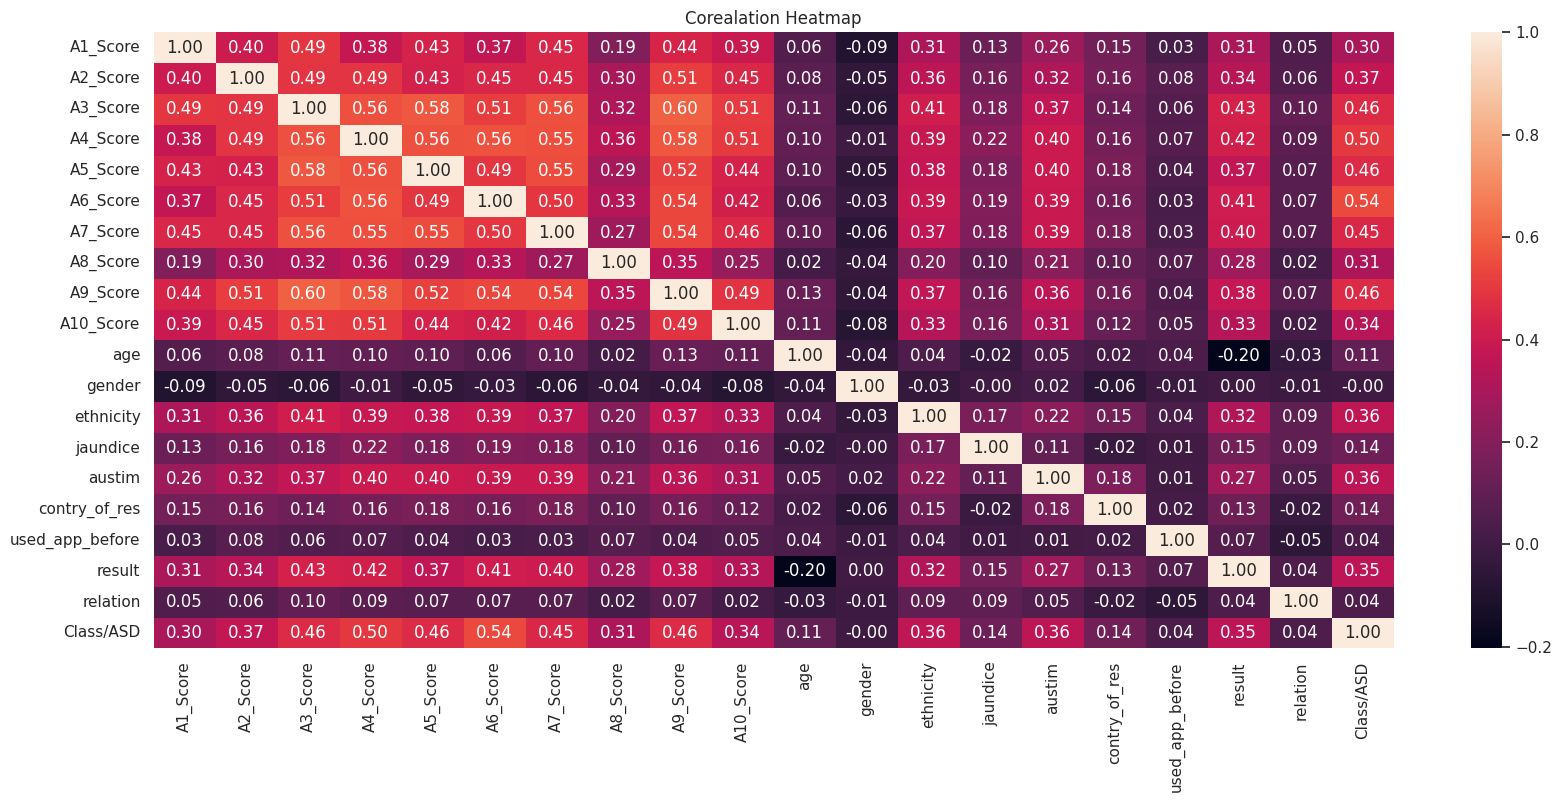

In [36]:
plt.figure(figsize=((20, 8)))
sns.heatmap(df.corr(),annot=True,fmt='0.2f')
plt.title('Corealation Heatmap')
plt.show()


## Data Preprocessing

In [37]:
## function to replace outliers with mean


def replace_outliers_with_mean(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1

    lower=q1-1.5*iqr;
    upper_bound=q1+1.5*iqr
    median=df[column].median()
    df[column]=df[column].apply(lambda x: median if x<lower or x>upper_bound else x)
    return df

In [38]:
df=replace_outliers_with_mean(df,'age')
df=replace_outliers_with_mean(df,'result')

## TRAIN TEST SPLIT

In [39]:
X=df.drop('Class/ASD',axis=1)
Y=df['Class/ASD']

In [43]:
X_tarin,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_tarin.shape,X_test.shape)
print(Y_train.shape,Y_test.shape)

(640, 19) (160, 19)
(640,) (160,)


In [44]:
Y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [45]:
Y_test.value_counts()

,count
Class/ASD,
0,124
1,36


SMOTE (SYNTEHTIC MINORITY OVERSAMPLING TECHNIQUE)

In [46]:
smote=SMOTE(random_state=42)


In [49]:
X_train_smote,Y_train_smote=smote.fit_resample(X_tarin,Y_train)

In [50]:
print(Y_train_smote.shape)
print(Y_train_smote.value_counts())

(1030,)
Class/ASD
1    515
0    515
Name: count, dtype: int64


## Model training

In [53]:
models={
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'XGBClassifier':XGBClassifier(random_state=42)
}


In [55]:
## dictionary to store cross validation score

cv_score={}

for modelname,model in models.items():
  print(f'{modelname}:\n')
  scores=cross_val_score(model,X_train_smote,Y_train_smote,cv=5,scoring='accuracy')
  cv_score[modelname]=scores
  print(f'Cross Validation Score: {cv_score[modelname].mean()}\n')
  print('*'*80)

DecisionTreeClassifier:

Cross Validation Score: 0.8281553398058252

********************************************************************************
RandomForestClassifier:

Cross Validation Score: 0.9058252427184467

********************************************************************************
XGBClassifier:

Cross Validation Score: 0.8970873786407767

********************************************************************************


In [57]:
print(cv_score)

{'DecisionTreeClassifier': array([0.7815534 , 0.82038835, 0.86893204, 0.85436893, 0.81553398]), 'RandomForestClassifier': array([0.88349515, 0.92718447, 0.89805825, 0.91747573, 0.90291262]), 'XGBClassifier': array([0.86407767, 0.92718447, 0.89805825, 0.90776699, 0.88834951])}


## Model selection

In [61]:
decision_tree_model=DecisionTreeClassifier(random_state=42)

random_forest_model=RandomForestClassifier(random_state=42)

xgb_model=XGBClassifier(random_state=42)


In [58]:
param_grid_dt={
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

param_grid_rf={
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,4,5]
}
param_grid_xgb={
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7,10],
    'learning_rate':[0.01,0.1,0.2]
}

In [66]:
random_search_Cv_dt=RandomizedSearchCV(estimator=decision_tree_model,param_distributions=param_grid_dt,n_iter=100,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_search_Cv_dt.fit(X_train_smote,Y_train_smote)
print(f'Best Parameters: {random_search_Cv_dt.best_params_}')
print(f'Best Score: {random_search_Cv_dt.best_score_}')


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'entropy'}
Best Score: 0.8466019417475728


In [67]:
random_search_Cv_rf=RandomizedSearchCV(estimator=random_forest_model,param_distributions=param_grid_rf,n_iter=100,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_search_Cv_rf.fit(X_train_smote,Y_train_smote)
print(f'Best Parameters: {random_search_Cv_rf.best_params_}')
print(f'Best Score: {random_search_Cv_rf.best_score_}')


Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Best Score: 0.9029126213592233


In [68]:
random_search_Cv_b_xgb=RandomizedSearchCV(estimator=xgb_model,param_distributions=param_grid_xgb,n_iter=100,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_search_Cv_b_xgb.fit(X_train_smote,Y_train_smote)
print(f'Best Parameters: {random_search_Cv_b_xgb.best_params_}')
print(f'Best Score: {random_search_Cv_b_xgb.best_score_}')


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 36 is smaller than n_iter=100. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best Score: 0.9067961165048544


In [70]:
best_model=None
best_score=0

if random_search_Cv_dt.best_score_>best_score:
  best_score=random_search_Cv_dt.best_score_
  best_model=random_search_Cv_dt.best_estimator_
  best_model_name='DecisionTreeClassifier'

if random_search_Cv_rf.best_score_>best_score:
  best_score=random_search_Cv_rf.best_score_
  best_model=random_search_Cv_rf.best_estimator_
  best_model_name='RandomForestClassifier'

if random_search_Cv_b_xgb.best_score_>best_score:
  best_score=random_search_Cv_b_xgb.best_score_
  best_model=random_search_Cv_b_xgb.best_estimator_
  best_model_name='XGBClassifier'

print(f'Best Model: {best_model_name}')
print(f'Best Score: {best_score}')
print(f'Best Parameters: {best_model.get_params()}')

Best Model: XGBClassifier
Best Score: 0.9067961165048544
Best Parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [72]:
with open('best_model.pkl','wb') as f:
  pickle.dump(best_model,f)
  print('Best model saved successfully')

Best model saved successfully


In [74]:
y_pred=best_model.predict(X_test)
accuracy=accuracy_score(Y_test,y_pred)
print(f'Accuracy: {accuracy}')
print("Classification report is :\n",classification_report(Y_test,y_pred))
print("Confusion Matrix :\n",confusion_matrix(Y_test,y_pred))

Accuracy: 0.8
Classification report is :
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       124
           1       0.55      0.64      0.59        36

    accuracy                           0.80       160
   macro avg       0.72      0.74      0.73       160
weighted avg       0.81      0.80      0.81       160

Confusion Matrix :
 [[105  19]
 [ 13  23]]


In [99]:
input_dict = {
    "ID": 1,
    "A1_Score": 1,
    "A2_Score": 0,
    "A3_Score": 1,
    "A4_Score": 0,
    "A5_Score": 1,
    "A6_Score": 0,
    "A7_Score": 1,
    "A8_Score": 0,
    "A9_Score": 1,
    "A10_Score":1,
    "age":38.17274623,
    "gender": "f",
    "ethnicity": "?",
    "jaundice": "no",
    "austim": "no",
    "contry_of_res": "Austria",
    "used_app_before": "no",
    "result": 6.351166,
    "age_desc": "18 and more",
    "relation": "Self",
    "Class/ASD": "NO"
}
input_df = pd.DataFrame([input_dict])
input_df.drop(['ID','age_desc','Class/ASD'],axis=1,inplace=True)
# input_df

input_df['age']=input_df['age'].astype(int)

input_df=replace_outliers_with_mean(input_df,'age')
input_df=replace_outliers_with_mean(input_df,'result')
input_df['ethnicity'].replace({'?':'Others','others':'Others'},inplace=True)
input_df['contry_of_res']=input_df['contry_of_res'].replace(country_mapping)
input_df['relation']=input_df['relation'].replace({"?":"Others","Relative":"Others","Parent":"Others","Health care professional":"Others"})

# input_df.head()

import pickle

with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
    print('Encoders loaded successfully')
for col in input_df.columns:
  if col in encoders:
    input_df[col]=encoders[col].transform(input_df[col])

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

prediction = model.predict(input_df)
print("Prediction is : ",prediction[0])




Encoders loaded successfully
Prediction is :  0


<ipython-input-99-58445573ff95>:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  input_df['ethnicity'].replace({'?':'Others','others':'Others'},inplace=True)
